# Simple Linear Regression

This notebook covers simple (single-feature) linear regression: fitting a line to data with `scikit-learn`, interpreting the slope and intercept, and making predictions.

**What is Simple Linear Regression?**
- Models the relationship between **one input feature** and a continuous target as a straight line: `y = mx + b`
- `m` (slope / coefficient) tells you how much `y` changes per unit change in `x`
- `b` (intercept) is the predicted `y` when `x = 0`
- Fit by minimizing the sum of squared errors between predictions and actual values (Ordinary Least Squares)

**Note:** For evaluation metrics, see [04_regression_metrics.ipynb](04_regression_metrics.ipynb)

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## 1. Load and Explore the Data

`placement.csv` has two columns: `cgpa` (a student's CGPA) and `package` (their placement package in LPA). The goal is to predict `package` from `cgpa`.

In [2]:
df = pd.read_csv('placement.csv')
df.head()

,cgpa,package
0,6.48,2.37
1,6.84,2.79
2,4.76,1.72
3,8.54,4.32
4,5.11,2.22


In [3]:
df.shape

(200, 2)

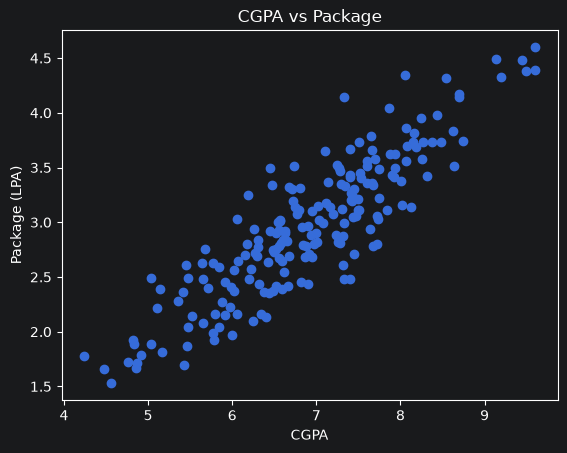

In [4]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package (LPA)')
plt.title('CGPA vs Package')
plt.show()

## 2. Train / Test Split

Keep a portion of the data unseen so we can check how well the model generalizes.

In [5]:
X = df.iloc[:, 0:1]   # keep as DataFrame (2D) — sklearn expects 2D input
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
X_train.shape, X_test.shape

((160, 1), (40, 1))

## 3. Fit the Model

All scikit-learn estimators follow the same pattern: create → `fit()` → `predict()`.

In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.53]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['cgpa']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.717
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [7]:
m = lr.coef_[0]
b = lr.intercept_
print(f"Slope (m): {m:.4f}")
print(f"Intercept (b): {b:.4f}")

Slope (m): 0.5338
Intercept (b): -0.7170


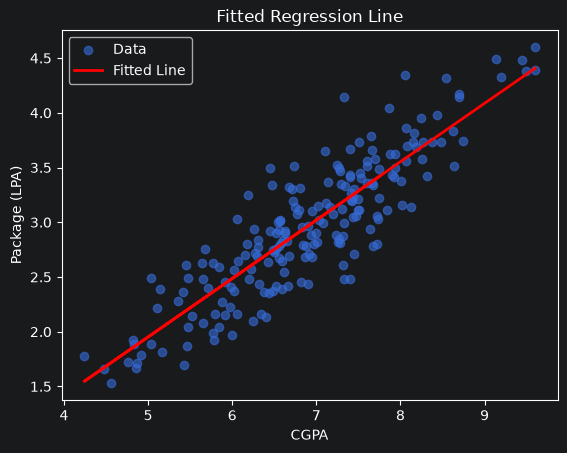

In [8]:
# Visualize the fitted line against the training data
plt.scatter(df['cgpa'], df['package'], alpha=0.6, label='Data')
plt.plot(X_train, lr.predict(X_train), color='red', linewidth=2, label='Fitted Line')
plt.xlabel('CGPA')
plt.ylabel('Package (LPA)')
plt.title('Fitted Regression Line')
plt.legend()
plt.show()

## 4. Make Predictions

Predict the package for a new CGPA value, and confirm it matches the manual `y = mx + b` calculation.

In [9]:
single_prediction = lr.predict(X_test.iloc[0:1])
print(f"Predicted package: {single_prediction[0]:.4f}")

Predicted package: 2.4856


In [10]:
# Sanity check: same result using the raw slope/intercept formula
cgpa_value = X_test.iloc[0].values[0]
manual_prediction = m * cgpa_value + b
print(f"Manual calculation: {manual_prediction:.4f}")
print(f"Match: {np.isclose(single_prediction[0], manual_prediction)}")

Manual calculation: 2.4856
Match: True


## 5. Interpreting Slope and Intercept

- **Slope (m = 0.5338):** For every 1.0 increase in CGPA, the predicted package increases by ~0.53 LPA
- **Intercept (b = -0.7170):** When CGPA = 0, the model predicts ~-0.72 LPA (not meaningful here, but mathematically part of the line)

To evaluate how well this model performs, see [04_regression_metrics.ipynb](04_regression_metrics.ipynb) for MAE, RMSE, R², etc.

---
## Simple Linear Regression Cheat Sheet

### Data Format & Splitting
| Code | Description |
|---|---|
| `df.iloc[:, 0:1]` | Select one column as 2D (keep as DataFrame) |
| `df.iloc[:, 0]` | ❌ Don't use — results in 1D Series |
| `train_test_split(X, y, test_size=0.2)` | Split into 80/20 train/test |

### Model Fitting & Prediction
| Code | Description |
|---|---|
| `lr = LinearRegression()` | Create an OLS estimator |
| `lr.fit(X_train, y_train)` | Fit the model — `X_train` must be 2D |
| `lr.predict(X_test)` | Predict target values |
| `lr.coef_` | Learned slope(s) — array with one element per feature |
| `lr.intercept_` | Learned intercept (`b`) |

### Interpretation
| Concept | Meaning |
|---|---|
| Slope | Change in `y` per unit change in `x` |
| Intercept | Predicted `y` when `x = 0` (often not meaningful) |
| Line: `y = m*x + b` | Fitted model in its simplest form |